## Section 1

In [6]:
import numpy as np
import matplotlib.pyplot as plt

file_path = "nma_steinmetz_spiketimes_cori_20161214_f32.npz"

# allow_pickle=True is necessary for this specific dataset 
# because it contains arrays of different lengths (ragged arrays)
spike_times = np.load(file_path, allow_pickle=True)

if isinstance(spike_times, np.lib.npyio.NpzFile):
    spike_times = spike_times['spike_times']

In [7]:
# Inspect the spike_times data
print("Type:", type(spike_times))
print("Shape:", spike_times.shape) # There are 734 entries in one dimension, and no other dimensions.
print("Data type:", spike_times.dtype)

# Show the first few elements (since it might be a ragged array)
print("First 5 elements:")
for i in range(min(5, len(spike_times))):
    print(f"Neuron {i}: {spike_times[i][:10] if len(spike_times[i]) > 10 else spike_times[i]}")  # First 10 spike times per neuron

Type: <class 'numpy.ndarray'>
Shape: (734,)
Data type: object
First 5 elements:
Neuron 0: [  0.8149    14.822467  24.9646    25.1436    38.8709    50.8208
  54.806866  59.511833  80.47037  127.09637 ]
Neuron 1: [0.0281    0.7068667 1.3172    1.4209666 1.7099333 3.6791666 3.7636333
 5.0386    5.4224334 5.435567 ]
Neuron 2: [ 77.22097   87.625336  87.732635  91.985634  92.068665 120.521065
 120.597664 120.60447  130.21873  130.36797 ]
Neuron 3: [ 16.713966  22.983267  89.849365 173.18523  173.25496  186.591
 201.8251   267.94446  306.29382  306.3262  ]
Neuron 4: [ 9.272734  14.822833  15.3421335 34.271465  34.6457    62.997135
 63.007465  63.048866  63.0917    63.1354   ]


In [8]:
# What is the Python type of the spike_times
idx = 321
print(
    type(spike_times[idx]),
    spike_times[idx].shape,
    sep='\n'
)

<class 'numpy.ndarray'>
(9723,)


Checking for when idx = 0 vs idx = 321 gives different result. They have different shape but same data type

In [9]:
# Checking the NumPy types of the values in the array
i_neurons = [0, 321, 64, 100]
i_print = slice(0, 5)  # To print the first five neurons in i_neurons

for i in i_neurons:
    print(
        "Neuron {}:".format(i),
        spike_times[i].dtype,
        spike_times[i][i_print],
        '\n',
        sep = '\n'
    )

Neuron 0:
float32
[ 0.8149   14.822467 24.9646   25.1436   38.8709  ]


Neuron 321:
float32
[1.0698667 1.1536334 1.2403667 1.7072    1.799    ]


Neuron 64:
float32
[1.3980334 3.2994666 3.3095334 4.3811336 5.5129666]


Neuron 100:
float32
[ 5.4681334  6.1993666 12.638634  13.250366  13.314867 ]




The data looks something like:

| . . . . . |
| . . . . . . . . |
| . . . |
| . . . . . . . |

- spike_times is 1D, its entries are NumPy arrays, and its length is the number of neurons (734): by indexing it, we select a subset of neurons.

- An array in spike_times is also 1D and corresponds to a single neuron; its entries are floating point numbers, and its length is the number of spikes attributed to that neuron. By indexing it, we select a subset of spike times for that neuron.

In [10]:
n_neurons = len(spike_times)
total_spikes_per_neuron = [len(spike_times_i) for spike_times_i in spike_times]

### Plotting total spike counts

Text(0.5, 1.0, 'Distribution of Total Spikes per Neuron')

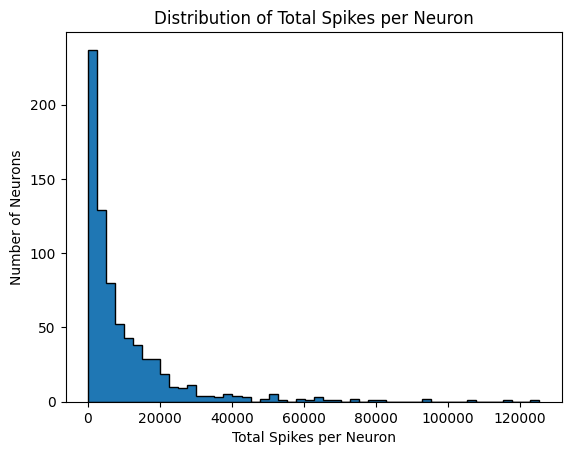

In [11]:
plt.hist(total_spikes_per_neuron, bins=50, histtype='stepfilled', edgecolor='black')
plt.xlabel('Total Spikes per Neuron')
plt.ylabel('Number of Neurons')
plt.title('Distribution of Total Spikes per Neuron')

In [12]:
mean_spike_count = np.mean(total_spikes_per_neuron)
frac_below_mean = (total_spikes_per_neuron < mean_spike_count).mean()
print(f"Mean spike count per neuron: {mean_spike_count:.2f}")
print(f"Percentage of neurons with spike count below mean: {frac_below_mean:2.1%}")

Mean spike count per neuron: 10319.35
Percentage of neurons with spike count below mean: 68.0%


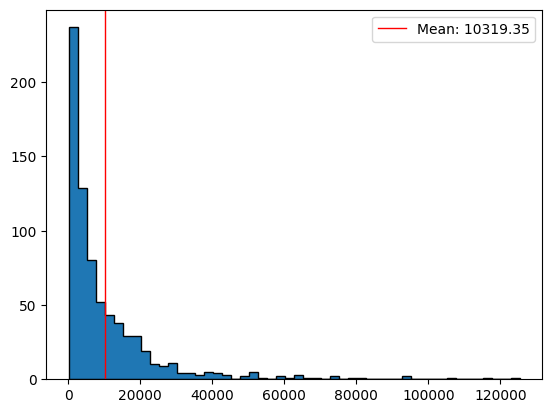

In [13]:
# adding the avg spike into the histogram
plt.hist(total_spikes_per_neuron, bins=50, histtype='stepfilled', edgecolor='black')
plt.axvline(mean_spike_count, color='red', linewidth=1, label=f'Mean: {mean_spike_count:.2f}')
plt.legend()

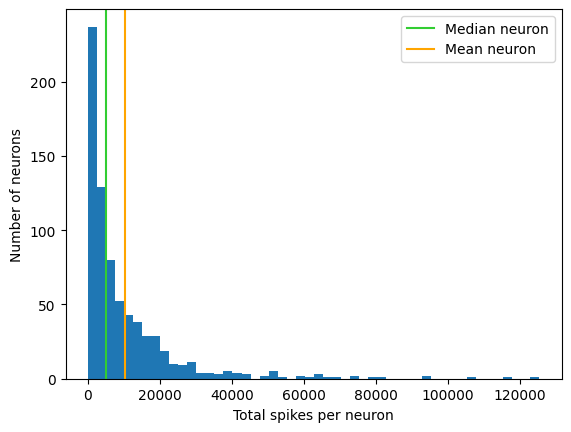

In [14]:
median_spike_count = np.median(total_spikes_per_neuron)

plt.hist(total_spikes_per_neuron, bins=50, histtype="stepfilled")
plt.axvline(median_spike_count, color="limegreen", label="Median neuron")
plt.axvline(mean_spike_count, color="orange", label="Mean neuron")
plt.xlabel("Total spikes per neuron")
plt.ylabel("Number of neurons")
plt.legend()

## Section 2

In [15]:
def restrict_spike_times(spike_times, interval):
  """Given a spike_time dataset, restrict to spikes within given interval.

  Args:
    spike_times (sequence of np.ndarray): List or array of arrays,
      each inner array has spike times for a single neuron.
    interval (tuple): Min, max time values; keep min <= t < max.

  Returns:
    np.ndarray: like `spike_times`, but only within `interval`
  """
  interval_spike_times = []
  for spikes in spike_times:
    interval_mask = (spikes >= interval[0]) & (spikes < interval[1])
    interval_spike_times.append(spikes[interval_mask])
  return np.array(interval_spike_times, object)

In [16]:
help(restrict_spike_times)

Help on function restrict_spike_times in module __main__:

restrict_spike_times(spike_times, interval)
    Given a spike_time dataset, restrict to spikes within given interval.

    Args:
      spike_times (sequence of np.ndarray): List or array of arrays,
        each inner array has spike times for a single neuron.
      interval (tuple): Min, max time values; keep min <= t < max.

    Returns:
      np.ndarray: like `spike_times`, but only within `interval`



In [17]:
t_interval = (5, 15)
interval_spike_times = restrict_spike_times(spike_times, t_interval)

original_counts = sum([len(spikes) for spikes in spike_times])
interval_counts = sum([len(spikes) for spikes in interval_spike_times])
frac_interval_spikes = interval_counts / original_counts
print(f"{frac_interval_spikes:.2%} of the total spikes are in the interval")

0.33% of the total spikes are in the interval


In [18]:
# Approximate the experiment duration
spike_times_flat = np.concatenate(spike_times)
experiment_duration = np.ptp(spike_times_flat)
interval_duration = t_interval[1] - t_interval[0]

fract_interval_time = interval_duration / experiment_duration
print(f"{fract_interval_time:.2%} of the total experiment time is in the interval")

0.37% of the total experiment time is in the interval


### Plotting spike trains and rasters

([], [])

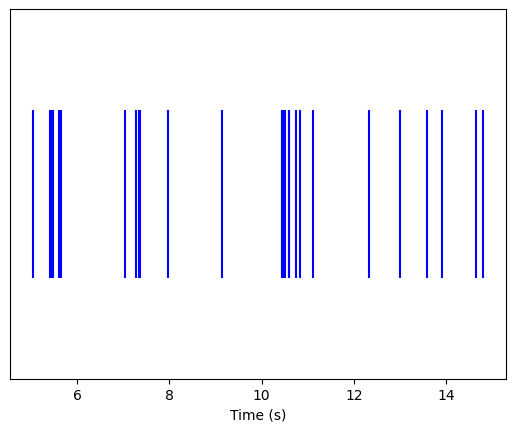

In [19]:
neuron_i = 1
plt.eventplot(interval_spike_times[neuron_i], color='blue')
plt.xlabel('Time (s)')
plt.yticks([])

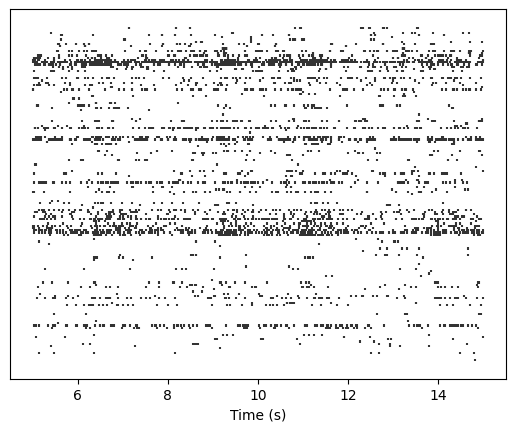

In [20]:
neuron_i = np.arange(0, len(spike_times), 5)
plt.eventplot(interval_spike_times[neuron_i], color=".2")
plt.xlabel("Time (s)")
plt.yticks([]);